In [1]:
import hoda
import tensorly as tl

print(tl.get_backend())
%pip freeze | grep moabb

cupy
moabb==1.0.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation
tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
datasets = [
    #BI2012(),
    #BI2013a(),
    #BI2014a(),
    #BI2014b(),
    #BI2015a(),
    #BI2015b(),
    BNCI2014_008(),
    #BNCI2014_009(),
    #BNCI2015_003(),
    #Cattan2019_VR(),
    #EPFLP300(),
    #Huebner2017(),
    #Huebner2018(),
    #Lee2019_ERP(),
    #Sosulski2019(),
]

evaluation = WithinSessionEvaluation(
    paradigm=paradigm,
    datasets=datasets,
    suffix="hoda_erp",
    overwrite=False,
    random_state=42,
    n_jobs=5,
)

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
/usr/local/lib/python3.10/dist-packages/moabb/analysis/results.py:93: RuntimeWarning: Setting non-standard config type: "MOABB_RESULTS"
  set_config("MOABB_RESULTS", osp.join(osp.expanduser("~"), "mne_data"))


In [3]:
from sklearn.pipeline import make_pipeline, Pipeline
from hoda.hoda import HODA, BTTDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import FunctionTransformer
import numpy as np
from hoda.tensorize import hankel_tensor

pipelines = dict()


pipelines['sLDA'] = make_pipeline(
        Vectorize(),
        LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)

pipelines['HODA'] = GridSearchCV(
        Pipeline([
            ('hoda', HODA(
                max_iter=256,
                tol=1e-8,
                init ='svd',
                shrinkage='lw',
                toeplitz=None,
                obj='rt',
                solver='lanczos',
                taper=False,
                keep_train_info=False,
                verbose=False,
            )),
            ('vec', Vectorize()),
            ('lda', LinearDiscriminantAnalysis())
        ]),
        dict(hoda__rank=list(range(1,8+1))),
        scoring='roc_auc',
    )

pipelines['BTTDA'] = Pipeline([
    ('bttda', BTTDA(
        max_blocks=16,
        info_crit='bic',
        hoda_params=dict(
            max_iter=256,
            tol=1e-8,
            init ='svd',
            shrinkage='lw',
            toeplitz=None,
            obj='rt',
            solver='lanczos',
            taper=False,
            keep_train_info=False,
            verbose=False,
        ),
        verbose=False,
        keep_train_info=False
    )),
    ('vec', Vectorize()),
    ('lda', LinearDiscriminantAnalysis())
])



In [4]:
#import warnings
#warnings.filterwarnings("ignore")

results = evaluation.process(pipelines)

BNCI2014-008-WithinSession:   0%|                                                                                                       | 0/8 [00:00<?, ?it/s]

No hdf5_path provided, models will not be saved.


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:312: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))


No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.


BNCI2014-008-WithinSession:  12%|███████████▊                                                                                  | 1/8 [01:51<13:03, 111.98s/it]/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:312: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))


...

BNCI2014-008-WithinSession:  75%|██████████████████████████████████████████████████████████████████████▌                       | 6/8 [10:39<03:29, 104.96s/it]/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:312: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))


No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.


BNCI2014-008-WithinSession:  88%|██████████████████████████████████████████████████████████████████████████████████▎           | 7/8 [12:52<01:54, 114.19s/it]/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:312: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))


No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.


BNCI2014-008-WithinSession: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [14:16<00:00, 107.10s/it]


In [5]:
results

,score,time,samples,subject,session,channels,n_sessions,dataset,pipeline
0,0.829933,3.063256,4200.0,1,0,8,1,BNCI2014-008,BTTDA
1,0.824082,4.064901,4200.0,2,0,8,1,BNCI2014-008,BTTDA
2,0.891682,4.003849,4200.0,3,0,8,1,BNCI2014-008,BTTDA
3,0.820327,2.441110,4200.0,4,0,8,1,BNCI2014-008,BTTDA
4,0.854375,0.502327,4200.0,5,0,8,1,BNCI2014-008,BTTDA
5,0.892475,3.159961,4200.0,6,0,8,1,BNCI2014-008,BTTDA
6,0.871386,4.014985,4200.0,7,0,8,1,BNCI2014-008,BTTDA
7,0.953214,2.079334,4200.0,8,0,8,1,BNCI2014-008,BTTDA
8,0.844784,0.330927,4200.0,1,0,8,1,BNCI2014-008,sLDA
9,0.819498,0.044084,4200.0,2,0,8,1,BNCI2014-008,sLDA


<Axes: xlabel='dataset', ylabel='score'>

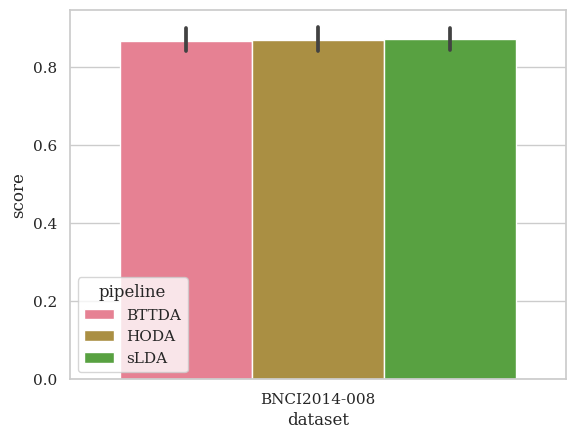

In [6]:
import seaborn as sns
order = results.groupby('pipeline')
order = order.score.aggregate('mean')
order = order.sort_values()

sns.barplot(
     data=results,
    y="score", x="dataset", hue="pipeline", hue_order=order.index,
)

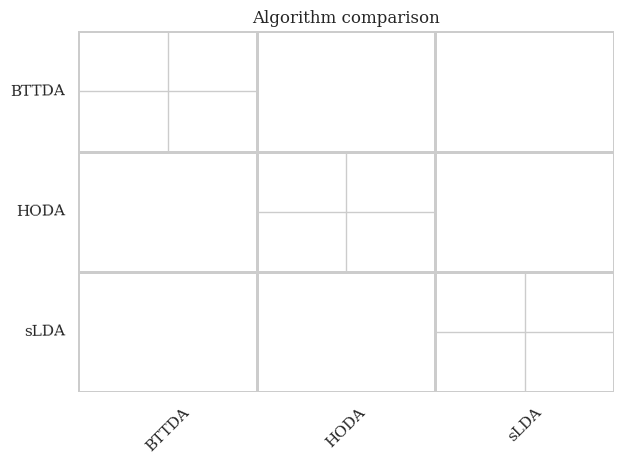

In [7]:
from moabb.analysis.meta_analysis import compute_dataset_statistics, find_significant_differences
from moabb.analysis.plotting import summary_plot
import matplotlib.pyplot as plt

stats = compute_dataset_statistics(results)
P, T = find_significant_differences(stats)
_ = summary_plot(P, T)

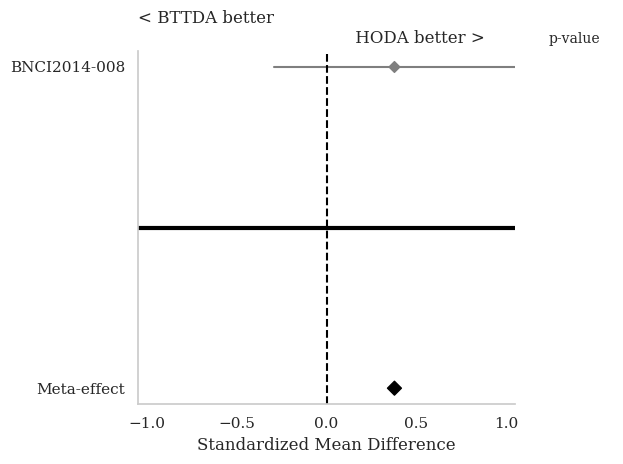

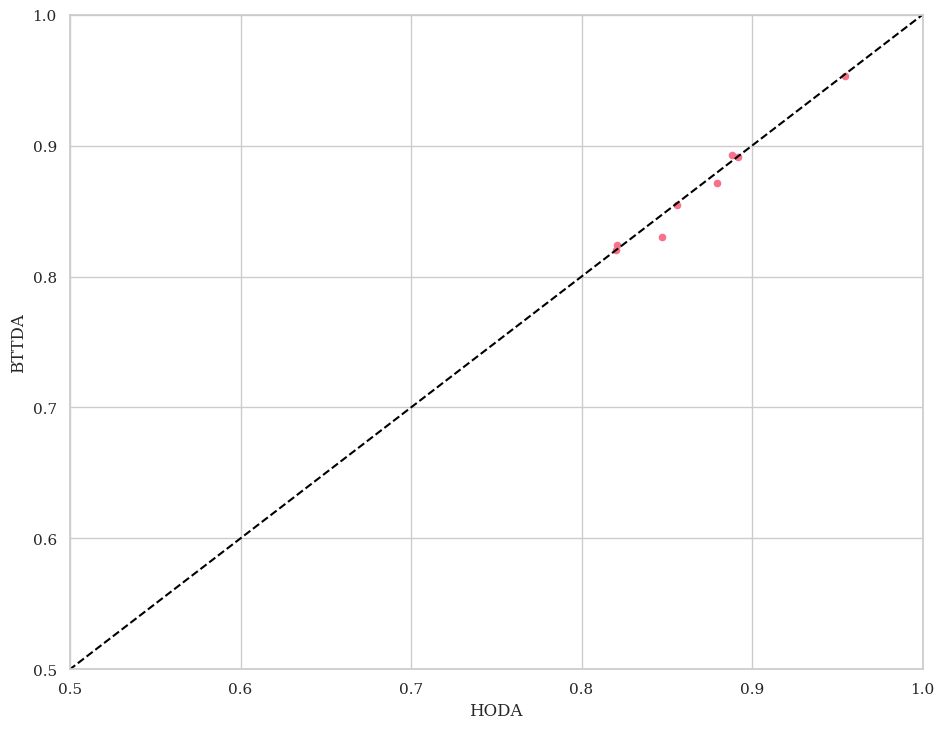

In [8]:
from moabb.analysis.plotting import meta_analysis_plot, paired_plot
_ = meta_analysis_plot(stats, 'HODA', 'BTTDA')
_  = paired_plot(results, 'HODA', 'BTTDA')